# Analysis of running times using ML

- Goal: Predict the time for a basic run based on various factors such as distance, altitude and avg heartrate
- ML: Linear Regression will be evaluated on the accuracy of running time predictions.

In [1]:
# Imports
import os
import sys

from google.cloud import bigquery

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load data

In [2]:
# Set up BigQuery client
def get_bq_client() -> bigquery.Client:
    try:
        creds = service_account.Credentials.from_service_account_info(
            st.secrets['gcp_service_account']
        )
        return bigquery.Client(credentials=creds, project=creds.project_id)
    except Exception:
        # Local dev fallback (requires GOOGLE_APPLICATION_CREDENTIALS)
        return bigquery.Client()

client = get_bq_client()

In [3]:
# Get table
GCP_PROJECT_ID = os.environ.get('GCP_PROJECT_ID')
BIGQUERY_DATASET_MARTS = os.environ.get('BIGQUERY_DATASET_MARTS')

TABLE_ID = f'{GCP_PROJECT_ID}.{BIGQUERY_DATASET_MARTS}.fct_activities'

table = client.get_table(TABLE_ID)
print(f'Columns: {[schema.name for schema in table.schema]}')
print(f'Rows: {table.num_rows}')

Columns: ['activity_id', 'athlete_id', 'gear_id', 'activity_name', 'discipline', 'start_date_local', 'activity_date_local', 'activity_year', 'activity_month', 'activity_weekday', 'activity_hour_local', 'distance_m', 'distance_km', 'moving_time_s', 'elapsed_time_s', 'avg_pace_min_per_km', 'avg_speed_kph', 'max_speed_kph', 'avg_speed_overall_kph', 'elevation_gain_m', 'avg_heartrate', 'max_heartrate', 'avg_cadence', 'energy_kj', 'avg_watts', 'max_watts', 'weighted_watts', 'kudos_count', 'comment_count', 'achievement_count', 'is_commute', 'is_trainer', 'has_heartrate', 'map_id', 'map_polyline', 'mart_loaded_at']
Rows: 436


In [4]:
# Query data and load into DataFrame
query = f'SELECT * FROM `{TABLE_ID}`'

job = client.query(query)
df = job.result().to_dataframe()
df.head()

,activity_id,athlete_id,gear_id,activity_name,discipline,start_date_local,activity_date_local,activity_year,activity_month,activity_weekday,...,weighted_watts,kudos_count,comment_count,achievement_count,is_commute,is_trainer,has_heartrate,map_id,map_polyline,mart_loaded_at
0,15410152310,133094316,None,Afternoon Swim,Swim,2025-08-10 14:20:27+00:00,2025-08-10,2025,8,1,...,NaN,0,0,0,False,False,True,a15410152310,,2026-02-23 14:02:30.654807+00:00
1,16293400857,133094316,None,Afternoon Swim,Swim,2025-10-29 15:44:01+00:00,2025-10-29,2025,10,4,...,NaN,2,0,0,False,True,True,a16293400857,,2026-02-23 14:02:30.654807+00:00
2,15866094742,133094316,None,Afternoon Swim,Swim,2025-09-19 17:00:23+00:00,2025-09-19,2025,9,6,...,NaN,1,0,0,False,False,True,a15866094742,,2026-02-23 14:02:30.654807+00:00
3,16649250076,133094316,None,Afternoon Swim,Swim,2025-12-04 15:48:01+00:00,2025-12-04,2025,12,5,...,NaN,1,0,0,False,True,True,a16649250076,,2026-02-23 14:02:30.654807+00:00
4,17374543198,133094316,None,Afternoon Swim,Swim,2026-02-12 15:29:45+00:00,2026-02-12,2026,2,5,...,NaN,1,0,0,False,True,True,a17374543198,,2026-02-23 14:02:30.654807+00:00


# EDA & Preprocessing

In [5]:
# Filter for running activities
df_runs = df[df['discipline'] == 'Run'].copy()

# df_runs[df_runs['avg_heartrate'].isna()]
# Decision: Drop rows with missing avg_heartrate (only 2)
df_runs = df_runs.dropna(subset=['avg_heartrate'])

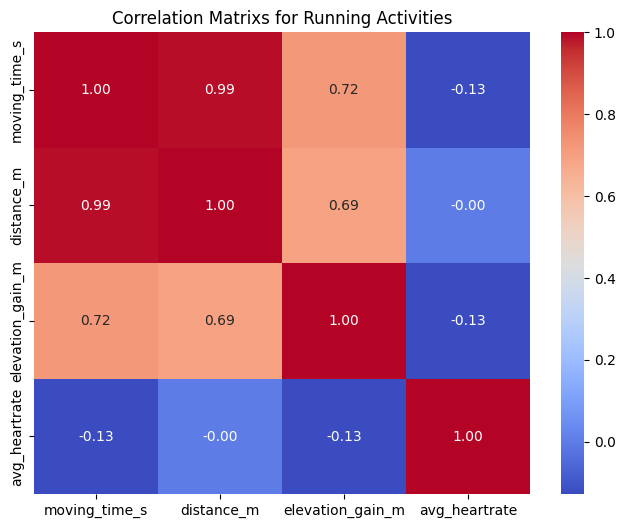

In [6]:
# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df_runs[['moving_time_s', 'distance_m', 'elevation_gain_m', 'avg_heartrate']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrixs for Running Activities")
plt.show()

- distance has the highest impact on the moving time
- elevation_gain has also a high impact on the moving time
- heartrate has a smaller impact

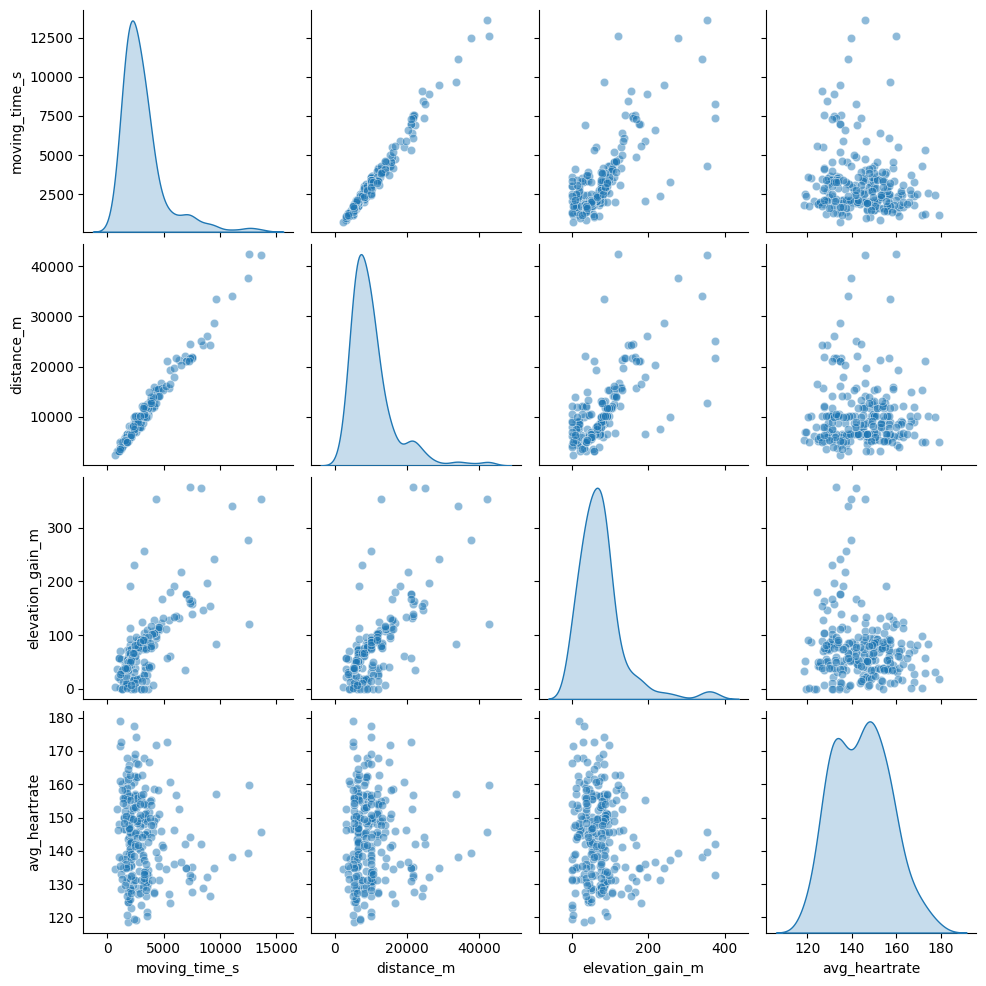

In [7]:
# Pairplot to visualize relationships between features and target
cols_to_compare = ['moving_time_s', 'distance_m', 'elevation_gain_m', 'avg_heartrate']
sns.pairplot(df_runs[cols_to_compare], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

# Model v1

- without avg_heartrate

In [8]:
# Features and target
features = ['distance_m', 'elevation_gain_m']
target = 'moving_time_s'
X = df_runs[features]
y = df_runs[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))

204 51


In [9]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
# Get coefficients of model
print(f"Intercept (Base time): {model.intercept_:.2f} seconds")
for col, coef in zip(features, model.coef_):
    print(f"Influence of {col}: {coef:.4f}")

Intercept (Base time): -117.53 seconds
Influence of distance_m: 0.3023
Influence of elevation_gain_m: 2.3360


In [11]:
# Predict
y_pred = model.predict(X_test)
y_pred[:5]

array([4019.61798112, 1197.48275156, 4391.35722542, 8338.95884593,
       3144.94718364])

In [12]:
# Metrics
r2_score_v1 = r2_score(y_test, y_pred)
mae_v1 = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2_score_v1:.4f}")
print(f"Mean Absolute Error: {mae_v1:.2f} seconds")


R² Score: 0.9652
Mean Absolute Error: 261.75 seconds


# Model v2

- with avg_heartrate

In [13]:
# Features and target
features_2 = ['distance_m', 'elevation_gain_m', 'avg_heartrate']
target = 'moving_time_s'
X_2 = df_runs[features_2]
y = df_runs[target]

# Train test split
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y, test_size=0.2, random_state=42)
print(len(X_train_2), len(X_test_2))

204 51


In [14]:
# Train model
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Get coefficients of model
print(f"Intercept (Base time): {model_2.intercept_:.2f} seconds")
for col, coef in zip(features_2, model_2.coef_):
    print(f"Influence of {col}: {coef:.4f}")

Intercept (Base time): 2504.20 seconds
Influence of distance_m: 0.3077
Influence of elevation_gain_m: 1.5097
Influence of avg_heartrate: -18.0158


In [16]:
# Predict
y_pred_2 = model_2.predict(X_test_2)
y_pred_2[:5]

array([4078.63558537, 1363.85860381, 4631.34318744, 8228.64385828,
       3105.73192009])

In [17]:
# Metrics
r2_score_v2 = r2_score(y_test_2, y_pred_2)
mae_v2 = mean_absolute_error(y_test_2, y_pred_2)

print(f"R² Score: {r2_score_v2:.4f}")
print(f"Mean Absolute Error: {mae_v2:.2f} seconds")

R² Score: 0.9822
Mean Absolute Error: 164.56 seconds


# Compare Results

In [ ]:
# Compare metrics side by side
metrics_df = pd.DataFrame({
    'Model': ['Basic', 'BPM'],
    'R² Score': [r2_score_v1, r2_score_v2],
    'MAE (s)': [mae_v1, mae_v2]
})
metrics_df

# Interpretations:
# - R² Score: The BPM model has a higher R² score compared to the Basic model, indicating that it explains more variance in the moving time.
# - MAE: The BPM model has a lower Mean Absolute Error compared to the Basic model, suggesting that it makes more accurate predictions on average.

,Model,R² Score,MAE (s)
0,Basic,0.965207,261.750709
1,BPM,0.982163,164.562180


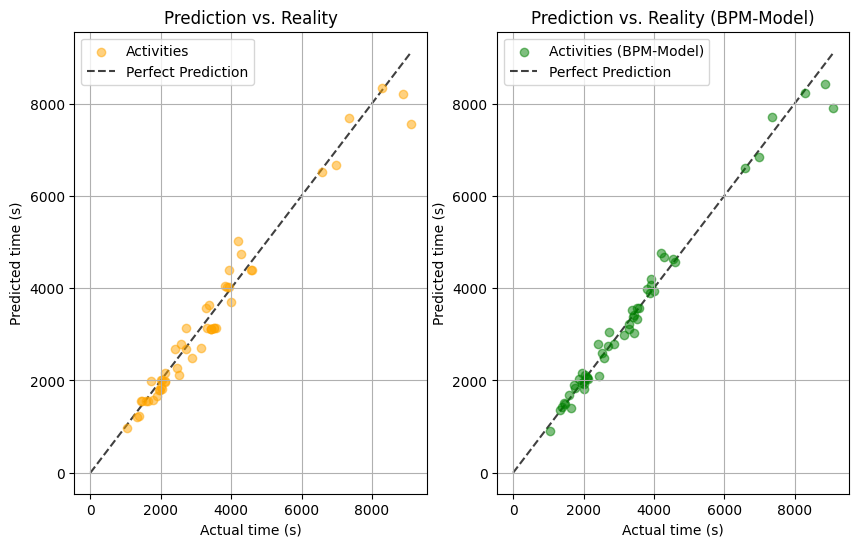

In [ ]:
# Compare predictions vs. actual values for both models
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='orange', label='Activities')

lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Prediction')

plt.xlabel('Actual time (s)')
plt.ylabel('Predicted time (s)')
plt.title('Prediction vs. Reality')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_2, y_pred_2, alpha=0.5, color='green', label='Activities (BPM-Model)')

lims = [0, max(y_test_2.max(), y_pred_2.max())]
plt.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Prediction')

plt.xlabel('Actual time (s)')
plt.ylabel('Predicted time (s)')
plt.title('Prediction vs. Reality (BPM-Model)')
plt.legend()
plt.grid(True)

plt.show()

# Interpretation:
# - The BPM model's predictions are more closely clustered around the perfect prediction line compared to the Basic model, indicating better performance in predicting moving times.

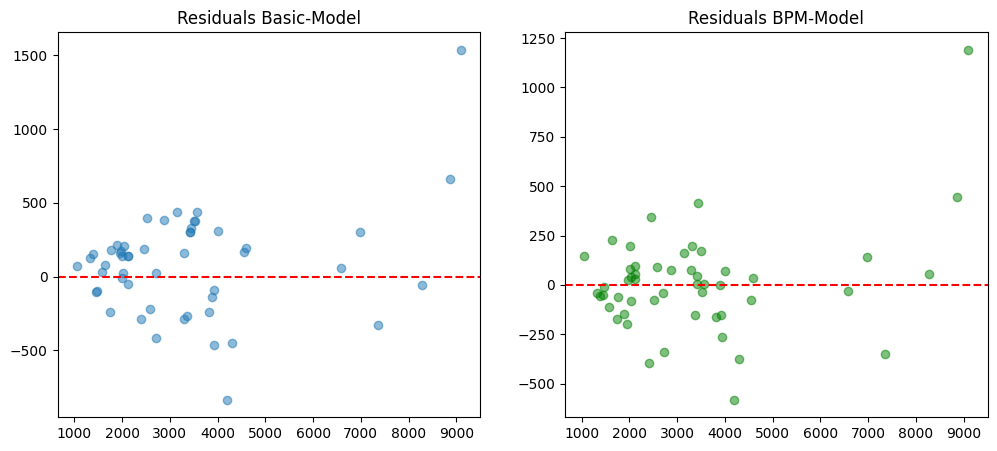

In [21]:
# Compare residuals for both models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test - y_pred, alpha=0.5, label='Basic')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Basic-Model")

plt.subplot(1, 2, 2)
plt.scatter(y_test_2, y_test_2 - y_pred_2, alpha=0.5, color='green', label='BPM-Model')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals BPM-Model")

plt.show()

# Interpretations:
# - The BPM model shows a more random distribution of residuals around zero, while the basic model has more systematic deviations, especially for longer runs.
# - This suggests that the BPM model captures some of the underlying factors affecting running time better than the basic model.
# - Both models still have some outliers, indicating that there are other factors influencing running time that are not captured by these features (e.g., weather, terrain, runner's condition).